In [1]:
from resources.imports import *

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchinfo import summary
import optuna                               # TODO: implement optuna for hyperparameter optimization

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import MLP

In [24]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            # nn.ReLU(),
            # nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim),
            # nn.ReLU(),
            # nn.Linear(128, input_dim)
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon

In [25]:
DAT = DATA(load=True, model="MLP")

In [26]:
DAT.train_in.shape

(3588, 714)

In [31]:
in_size = DAT.train_in.shape[-1]
h_size = 200

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 100

In [32]:
trainDS = Dataset_(DAT.train_in, DAT.train_in)
train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=False)

In [33]:
model = Autoencoder(input_dim=in_size, latent_dim=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [36]:
loss_list = []
for epoch in range(n_epochs):
    for x, y in train_dataloader:
        x, y = x.float(), y.float()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss_list.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: 0.6027
Epoch [2/100], Loss: 0.5843
Epoch [3/100], Loss: 0.5945
Epoch [4/100], Loss: 0.5979
Epoch [5/100], Loss: 0.6357
Epoch [6/100], Loss: 0.6183
Epoch [7/100], Loss: 0.6272
Epoch [8/100], Loss: 0.5992
Epoch [9/100], Loss: 0.6165
Epoch [10/100], Loss: 0.6000
Epoch [11/100], Loss: 0.6017
Epoch [12/100], Loss: 0.6576
Epoch [13/100], Loss: 0.6010
Epoch [14/100], Loss: 0.6183
Epoch [15/100], Loss: 0.6262
Epoch [16/100], Loss: 0.6256
Epoch [17/100], Loss: 0.6415
Epoch [18/100], Loss: 0.5941
Epoch [19/100], Loss: 0.6231
Epoch [20/100], Loss: 0.6450
Epoch [21/100], Loss: 0.6050
Epoch [22/100], Loss: 0.6029
Epoch [23/100], Loss: 0.6074
Epoch [24/100], Loss: 0.6403
Epoch [25/100], Loss: 0.5835
Epoch [26/100], Loss: 0.6268
Epoch [27/100], Loss: 0.6117
Epoch [28/100], Loss: 0.6096
Epoch [29/100], Loss: 0.6101
Epoch [30/100], Loss: 0.6350
Epoch [31/100], Loss: 0.6289
Epoch [32/100], Loss: 0.6100
Epoch [33/100], Loss: 0.6303
Epoch [34/100], Loss: 0.6091
Epoch [35/100], Loss: 0

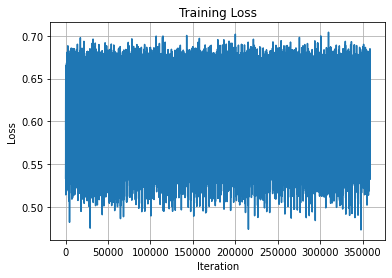

In [37]:
# Plot the loss
plt.plot(loss_list)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid()
plt.show()